In [1]:
from primordialpy.background import Background
from primordialpy.model import PotentialFunction
from primordialpy.perturbations import  Perturbations
import matplotlib.pyplot as plt

In [2]:
V = '0.5*m**2*phi**2'
param = {'m': 5.9e-6}

#Instancia de la clase potential
potential = PotentialFunction.function(V, param_values= param)

In [3]:
#Instancia de la clase background
background = Background(potential, phi0 = 17.5)
sol = background.solver()

/home/fpineda94/Documentos/Code/primordialpy/src/primordialpy/background.py:56: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(V / kinetic_term)


In [4]:
#Extrayendo datos de la clase background

N, phi, dphidN, H, a, aH, eps_H, eta_H = background.data().values()
background.save_background(path='./Data')
Nend = N[-1]
Nend

Saved to ./Data/background.dat


np.float64(78.14781478147815)

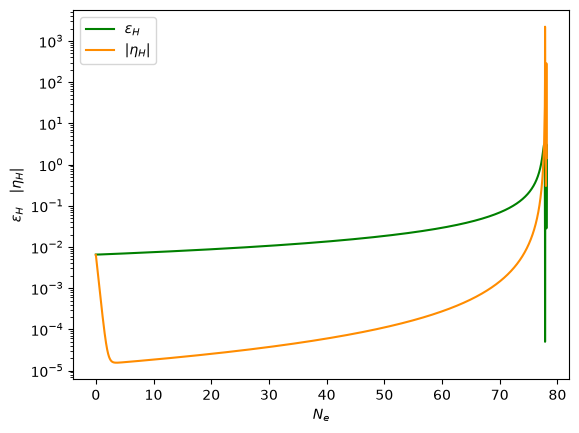

In [5]:
plt.plot(N, eps_H, label = r'$\epsilon_H$', color = 'green' )
plt.plot(N, abs(eta_H), label = r'$|\eta_H |$', color = 'darkorange')


plt.yscale('log')
plt.xlabel(r'$N_e$')
plt.ylabel(r'$\epsilon_H\quad |\eta_H|$')
plt.legend(loc = 'best')

In [7]:
pert = Perturbations(potential, background, scale= 'CMB', N_CMB = 60)
sol = pert.power_spectra_pivot()


Curvature power spectrum at pivot scale is 2.042163152697584e-09
Tensor to scalar ratio at pivot scale is 0.13437503627637978


In [8]:
PS = pert.power_spectrum()
pert.save_power_spectra(path ='./Data')

Computing P(k): 100%|██████████| 1000/1000 [01:25<00:00, 11.71it/s]


Saved to ./Data/power_spectra.dat


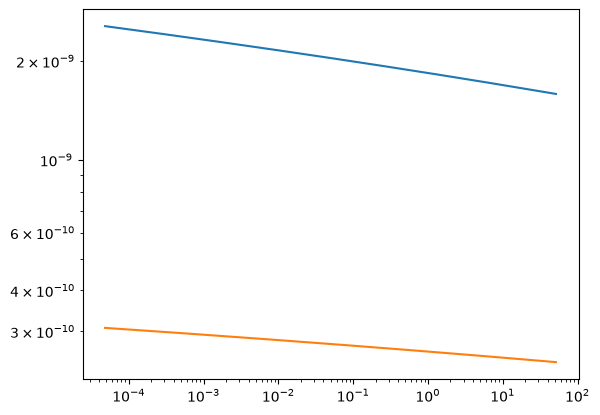

In [9]:
plt.loglog(pert.k_modes, PS[0])
plt.loglog(pert.k_modes, PS[1])


In [10]:
print(pert.spectral_tilts)


{'n_s': 0.9658710780954971, 'n_t': -0.01723968758990635}
